In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory

# xy grid test (FILEXY1M SKAL OPDATERES NÅR DEN BLIVER LAVET!!!)
filexy1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy2m_mb_cartesian.nc'
filexy2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy2m_mb_cartesian.nc'
filexy4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy4m_mb_cartesian.nc'

# z grid test (FILEXY1M SKAL OPDATERES NÅR DEN BLIVER LAVET!!!)
filez1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
filez2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
filez4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z01m_4m_cartesian.nc'

files = {
    'xy=1m': filexy1m,
    'xy=2m': filexy2m,
    'xy=4m': filexy4m,
    'z=1m' : filez1m,
    'z=2m' : filez2m,
    'z=4m' : filez4m
}

In [57]:
def percent_distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    norm = np.sqrt((ref_p[-1, 0]-ref_p[0, 0])**2 + (ref_p[-1, 1]-ref_p[0, 1])**2)
    return np.sqrt(dx**2 + dy**2) / norm * 100

def distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    return np.sqrt(dx**2 + dy**2)

def x_distance_error(ref_p, test_p):
    return test_p[-1, 0] - ref_p[-1, 0]

def y_distance_error(ref_p, test_p):
    return test_p[-1, 1] - ref_p[-1, 1]

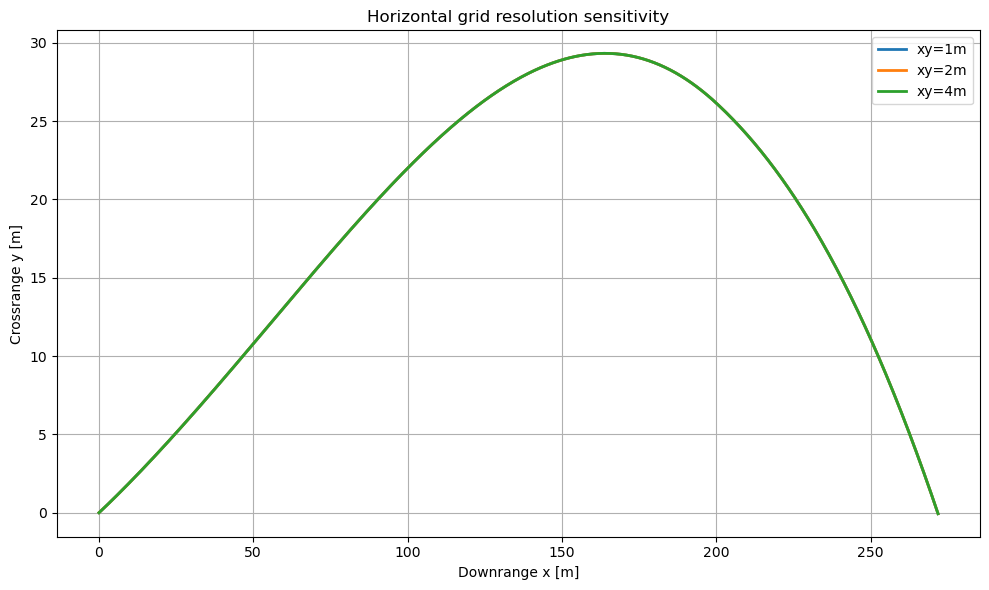

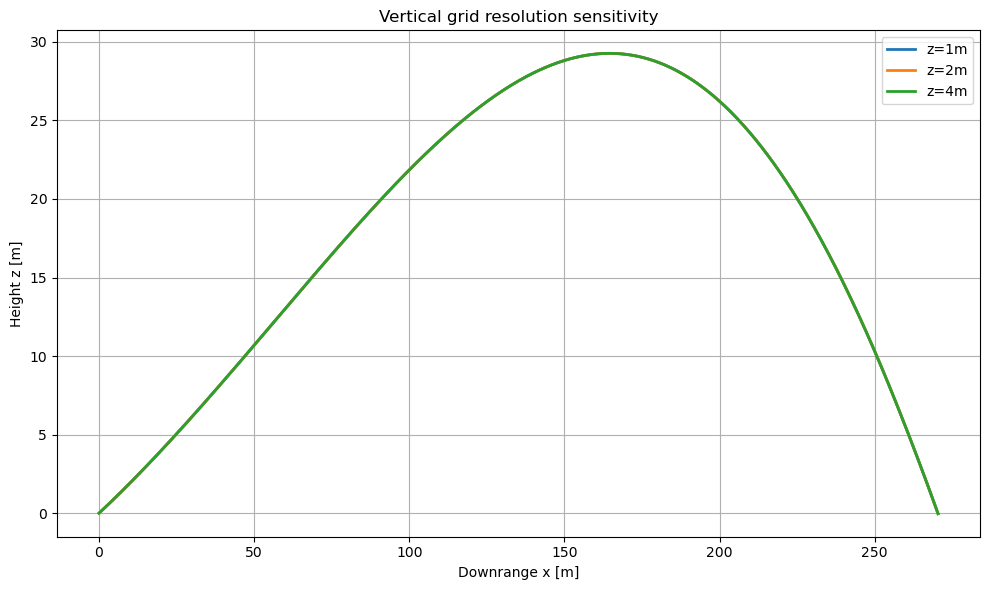

Fidelity errors

Horizontal grid sensitivity (reference = xy=1m)

xy=2m
Absolute landing error   : 0.0000 m
Percent landing error    : 0.0000 %
Carry distance error dx  : 0.0000 m
Lateral drift error dy   : 0.0000 m

xy=4m
Absolute landing error   : 0.0001 m
Percent landing error    : 0.0000 %
Carry distance error dx  : 0.0001 m
Lateral drift error dy   : 0.0000 m

Vertical grid sensitivity (reference = z=1m)

z=2m
Absolute landing error   : 0.0000 m
Percent landing error    : 0.0000 %
Carry distance error dx  : 0.0000 m
Lateral drift error dy   : 0.0000 m

z=4m
Absolute landing error   : 0.0013 m
Percent landing error    : 0.0005 %
Carry distance error dx  : 0.0013 m
Lateral drift error dy   : 0.0000 m


In [60]:
trajectories = {}

for key, file in files.items():

    wind = WindField(profile='rans', ds=file)

    traj = Trajectory(
        ball_speed=76.44384,
        launch_angle=10.4,
        spin_rate=2545,
        spin_axis=0,
        wind=wind
    )

    traj.solve(solver='euler', dt=0.01)
    trajectories[key] = traj


# Plot xy grid fidelity comparison
plt.figure(figsize=(10,6))

for key in ['xy=1m', 'xy=2m', 'xy=4m']:
    p = trajectories[key].p
    plt.plot(p[:,0], p[:,2], linewidth=2, label=key)

plt.xlabel('Downrange x [m]')
plt.ylabel('Crossrange y [m]')
plt.title('Horizontal grid resolution sensitivity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot z grid fidelity comparison
plt.figure(figsize=(10,6))

for key in ['z=1m', 'z=2m', 'z=4m']:
    p = trajectories[key].p
    plt.plot(p[:,0], p[:,2], linewidth=2, label=key)

plt.xlabel('Downrange x [m]')
plt.ylabel('Height z [m]')
plt.title('Vertical grid resolution sensitivity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Error analysis
print('Fidelity errors')
# XY reference = finest xy mesh
ref_xy = trajectories['xy=1m'].p

print('\nHorizontal grid sensitivity (reference = xy=1m)')
for key in ['xy=2m', 'xy=4m']:
    test_p = trajectories[key].p

    print(f'\n{key}')
    print(f'Absolute landing error   : {distance_error(ref_xy, test_p):.4f} m')
    print(f'Percent landing error    : {percent_distance_error(ref_xy, test_p):.4f} %')
    print(f'Carry distance error dx  : {x_distance_error(ref_xy, test_p):.4f} m')
    print(f'Lateral drift error dy   : {y_distance_error(ref_xy, test_p):.4f} m')

# Z reference = finest z mesh
ref_z = trajectories['z=1m'].p

print('\nVertical grid sensitivity (reference = z=1m)')
for key in ['z=2m', 'z=4m']:
    test_p = trajectories[key].p

    print(f'\n{key}')
    print(f'Absolute landing error   : {distance_error(ref_z, test_p):.4f} m')
    print(f'Percent landing error    : {percent_distance_error(ref_z, test_p):.4f} %')
    print(f'Carry distance error dx  : {x_distance_error(ref_z, test_p):.4f} m')
    print(f'Lateral drift error dy   : {y_distance_error(ref_z, test_p):.4f} m')